<a href="https://colab.research.google.com/github/s326327/Days-1---5-Data-Science/blob/main/Lesson3_How_Spread_Out_is_the_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Range of annual means: 8.1 F
Standard deviation: 1.82 F
Variance: 3.30 F squared
IQR: 2.30 F
Q1: 76.75 F  Q3: 79.04 F  IQR: 2.30 F
        mean_temp    std_dev
decade                      
1940    76.438763  14.063411
1950    78.963932  14.492344
1960    77.261451  14.836491
1970    76.809650  13.980896
1980    77.711771  14.498350
1990    78.031303  13.938951
2000    78.169039  14.015260
2010    78.712612  14.744170
2020    80.346207  14.387398
        mean_temp    std_dev     iqr
decade                              
1940    76.438763  14.063411  21.060
1950    78.963932  14.492344  23.085
1960    77.261451  14.836491  22.140
1970    76.809650  13.980896  20.520
1980    77.711771  14.498350  21.060
1990    78.031303  13.938951  21.420
2000    78.169039  14.015260  20.160
2010    78.712612  14.744170  21.420
2020    80.346207  14.387398  20.700
city: Austin
r

/tmp/ipykernel_15514/2141039355.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(annual['mean_temp_max_f'].values, labels=['Austin'])


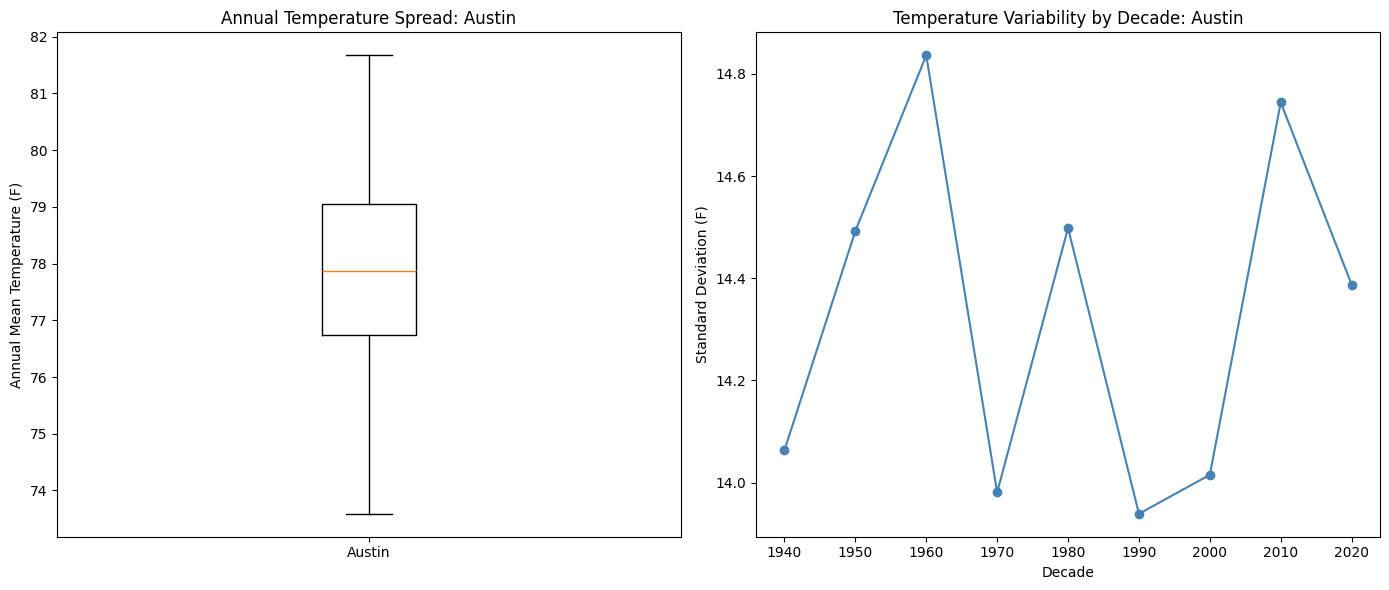

Saved spread statistics.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt


annual = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')


df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
temp_range = annual['mean_temp_max_f'].max() - annual['mean_temp_max_f'].min()
print(f'Range of annual means: {temp_range:.1f} F')
annual_std = annual['mean_temp_max_f'].std()
annual_var = annual['mean_temp_max_f'].var()

print(f'Standard deviation: {annual_std:.2f} F')
print(f'Variance: {annual_var:.2f} F squared')
from scipy.stats import iqr
annual_iqr = iqr(annual['mean_temp_max_f'])
print(f'IQR: {annual_iqr:.2f} F')

q1 = annual['mean_temp_max_f'].quantile(0.25)
q3 = annual['mean_temp_max_f'].quantile(0.75)
print(f'Q1: {q1:.2f} F  Q3: {q3:.2f} F  IQR: {q3 - q1:.2f} F')
df['decade'] = (df['year'] // 10) * 10
df[['year', 'decade']].head()
df['temp_max_f'] = df['temp_max'] * 9/5 + 32
df.columns

decade_spread = df.groupby('decade')['temp_max_f'].agg(
    mean_temp='mean',
    std_dev='std'
)

print(decade_spread)
decade_spread = df.groupby('decade')['temp_max_f'].agg(
    mean_temp='mean',
    std_dev='std',
    iqr=lambda x: iqr(x)
)

print(decade_spread)
def compute_spread(data, city_name):
    """
    Compute spread statistics for a city's annual temperature data.

    Parameters: data (Series) — annual mean temperatures
    city_name (str) — city label for print output

    Returns: dict of spread statistics
    """

    results = {
        'city': city_name,
        'range': data.max() - data.min(),
        'std_dev': data.std(),
        'variance': data.var(),
        'iqr': iqr(data),
        'q1': data.quantile(0.25),
        'q3': data.quantile(0.75)
    }
    return results

stats = compute_spread(annual['mean_temp_max_f'], 'Austin')
for key, val in stats.items():
    print(f'{key}: {val:.2f}' if isinstance(val, float) else f'{key}: {val}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1 — Boxplot of annual temperatures
ax1.boxplot(annual['mean_temp_max_f'].values, labels=['Austin'])
ax1.set_title('Annual Temperature Spread: Austin')
ax1.set_ylabel('Annual Mean Temperature (F)')

# Panel 2 — Standard deviation by decade
ax2.plot(decade_spread.index, decade_spread['std_dev'],
         marker='o', color='steelblue', linewidth=1.5)
ax2.set_title('Temperature Variability by Decade: Austin')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Standard Deviation (F)')

plt.tight_layout()
plt.show()
import json

with open('/content/drive/MyDrive/Data Science/Data/spread_stats_austin.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Saved spread statistics.')